<a href="https://colab.research.google.com/github/mariazafran/Herding-Behaviour-Learning/blob/main/01-Learning-herding-analysis-%20May%2031%2C%202026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install yfinance pandas statsmodels arch

import yfinance as yf
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 22.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import requests

url = "https://en.wikipedia.org/wiki/FTSE_100_Index"

# Trick: pretend to be a browser
headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers)

# Now read tables from page content
tables = pd.read_html(response.text)

# Find correct table
for i, table in enumerate(tables):
    print(i, table.columns)

/tmp/ipykernel_10907/1884480788.py:14: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


0 Index([0, 1], dtype='int64')
1 Index(['ICB Supersector', 'Marketcap (£ billion)[28]'], dtype='object')
2 Index([0, 1], dtype='int64')
3 Index([0, 1], dtype='int64')
4 Index([0, 1, 2], dtype='int64')
5 MultiIndex([(           'Year',          'Year'),
            (  'Closing level', 'Closing level'),
            ('Change in index',      '(points)'),
            ('Change in index',           '(%)')],
           )
6 Index(['Company', 'Ticker',
       'FTSE industry classification benchmark sector[39]'],
      dtype='object')
7 Index(['vte FTSE 100 companies of the United Kingdom → FTSE 250', 'vte FTSE 100 companies of the United Kingdom → FTSE 250.1'], dtype='object')
8 Index(['vteMajor European stock market indices', 'vteMajor European stock market indices.1'], dtype='object')
9 Index(['Links to related articles', 'Links to related articles.1'], dtype='object')
10 Index(['vteMajor United Kingdom stock market indices', 'vteMajor United Kingdom stock market indices.1'], dtype='object')
1

In [ ]:
ftse = tables[6]

tickers = ftse['Ticker'].tolist()

# Add ".L"
tickers = [t + ".L" for t in tickers]

print("Total firms:", len(tickers))
print(tickers[:10])

Total firms: 100
['III.L', 'ADM.L', 'AAF.L', 'ALW.L', 'AAL.L', 'ANTO.L', 'ABF.L', 'AZN.L', 'AUTO.L', 'AV.L']


In [ ]:
tickers = ftse['Ticker']

In [ ]:
print(ftse.columns)

Index(['Company', 'Ticker',
       'FTSE industry classification benchmark sector[39]'],
      dtype='object')


Save FTSE company list

In [ ]:
ftse = tables[6]

# Save table
ftse.to_csv("ftse100_companies.csv", index=False)

Download Stock price data

In [ ]:
clean_tickers = []

for t in tickers:
    if isinstance(t, str):
        # Fix BT.A → BT-A format
        t = t.replace('.', '-')
        clean_tickers.append(t + ".L" if ".L" not in t else t)

print("Cleaned tickers:", len(clean_tickers))

Cleaned tickers: 100


In [ ]:
import yfinance as yf

all_prices = []

for t in clean_tickers:
    try:
        data = yf.download(t, start="2018-01-01", end="2024-12-31")

        if 'Close' in data.columns:
            series = data['Close'].dropna()

            if not series.empty:
                series.name = t
                all_prices.append(series)

        print(t, "✅")

    except:
        print(t, "❌ skipped")

/tmp/ipykernel_10907/177432917.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(t, start="2018-01-01", end="2024-12-31")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_10907/177432917.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(t, start="2018-01-01", end="2024-12-31")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_10907/177432917.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(t, start="2018-01-01", end="2024-12-31")


III.L ✅
ADM.L ✅


[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_10907/177432917.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(t, start="2018-01-01", end="2024-12-31")


AAF.L ✅


[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_10907/177432917.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(t, start="2018-01-01", end="2024-12-31")


...

VOD.L ✅


[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_10907/177432917.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(t, start="2018-01-01", end="2024-12-31")


WEIR.L ✅


[*********************100%***********************]  1 of 1 completed

WTB.L ✅


In [ ]:
print("Number of valid firms:", len(all_prices))

prices = pd.concat(all_prices, axis=1)

print("Dataset shape:", prices.shape)

Number of valid firms: 99
Dataset shape: (1767, 99)


In [ ]:
prices = prices.fillna(method='ffill')
prices = prices.dropna(axis=1, how='all')

print("Clean dataset:", prices.shape)

Clean dataset: (1767, 99)


/tmp/ipykernel_10907/1986939782.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  prices = prices.fillna(method='ffill')


In [ ]:
print(len(all_prices))

99


In [ ]:
returns = prices.pct_change().dropna()

print(returns.shape)

(619, 99)


In [ ]:
Rm = returns.mean(axis=1)

In [ ]:
CSAD = (returns.sub(Rm, axis=0)).abs().mean(axis=1)

df = pd.DataFrame({
    "CSAD": CSAD,
    "Rm": Rm
}).dropna()

print(df.head())

                CSAD        Rm
Date                          
2022-07-19  0.009319  0.012910
2022-07-20  0.010087  0.001112
2022-07-21  0.012903  0.009763
2022-07-22  0.010790  0.003631
2022-07-25  0.012294 -0.001568


In [ ]:
# Center market return
df['Rm_c'] = df['Rm'] - df['Rm'].mean()

# Core terms
df['abs_Rm'] = df['Rm_c'].abs()
df['Rm_sq'] = df['Rm_c']**2

# Crisis dummy
df['crisis'] = ((df.index >= '2020-01-01') &
                (df.index <= '2021-12-31')).astype(int)

# Down-market (asymmetry)
df['down'] = (df['Rm_c'] < 0).astype(int)

In [ ]:
!pip install arch

In [ ]:
from arch import arch_model

am = arch_model(df['Rm']*100, vol='Garch', p=1, q=1)
res = am.fit(disp='off')

df['volatility'] = res.conditional_volatility / 100

In [ ]:
df[['volatility']].head()

,volatility
Date,
2022-07-19,0.009035
2022-07-20,0.009243
2022-07-21,0.008745
2022-07-22,0.008712
2022-07-25,0.008337


In [ ]:
df['Rm_sq_crisis'] = df['Rm_sq'] * df['crisis']
df['Rm_sq_vol'] = df['Rm_sq'] * df['volatility']
df['Rm_sq_down'] = df['Rm_sq'] * df['down']

In [ ]:
import statsmodels.api as sm

In [ ]:
import statsmodels.api as sm

# Define dependent variable
y = df['CSAD']

# Define independent variables
X = df[['abs_Rm','Rm_sq',
        'crisis','volatility','down',
        'Rm_sq_crisis','Rm_sq_vol','Rm_sq_down']]

# Add constant
X = sm.add_constant(X)

print("Variables ready ✅")

Variables ready ✅


In [ ]:
model = sm.OLS(y, X).fit(cov_type='HC3')
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   CSAD   R-squared:                       0.269
Model:                            OLS   Adj. R-squared:                  0.261
Method:                 Least Squares   F-statistic:                     20.98
Date:                Sun, 31 May 2026   Prob (F-statistic):           1.95e-22
Time:                        21:53:32   Log-Likelihood:                 2871.8
No. Observations:                 619   AIC:                            -5730.
Df Residuals:                     612   BIC:                            -5699.
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.0056      0.001      5.403   

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 8, but rank is 6
  warnings.warn('covariance of constraints does not have full '


In [ ]:
prices.to_csv("stock_prices_clean.csv")

In [ ]:
returns.to_csv("stock_returns.csv")

In [ ]:
df.to_csv("final_dataset.csv")

In [ ]:
from google.colab import files

files.download("stock_prices_clean.csv")
files.download("stock_returns.csv")
files.download("final_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
%%writefile my_analysis.py

# paste your full final code here manually

Writing my_analysis.py


In [ ]:
files.download("my_analysis.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
results = pd.DataFrame({
    "coef": model.params,
    "p_value": model.pvalues,
    "t_stat": model.tvalues
})

results.to_csv("regression_results.csv")

files.download("regression_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

os.makedirs('/content/drive/MyDrive/PhD_Research', exist_ok=True)

print("Folder created ✅")

Folder created ✅


In [ ]:
df.to_csv('/content/drive/MyDrive/PhD_Research/final_dataset.csv', index=False)

In [ ]:
prices.to_csv('/content/drive/MyDrive/PhD_Research/stock_prices.csv', index=False)
returns.to_csv('/content/drive/MyDrive/PhD_Research/stock_returns.csv', index=False)

In [ ]:
os.makedirs('/content/drive/MyDrive/PhD_Research/Data', exist_ok=True)
os.makedirs('/content/drive/MyDrive/PhD_Research/Results', exist_ok=True)
os.makedirs('/content/drive/MyDrive/PhD_Research/Code', exist_ok=True)

In [ ]:
df.to_csv('/content/drive/MyDrive/PhD_Research/Data/final_dataset.csv', index=False)

In [ ]:
# OLD MODEL (keep for comparison)
# X = sm.add_constant(df[['abs_Rm','Rm_sq',
#                         'crisis','volatility','down',
#                         'Rm_sq_crisis','Rm_sq_vol','Rm_sq_down']])
# model_old = sm.OLS(y, X).fit(cov_type='HC3')
# print(model_old.summary())

In [ ]:
# NEW IMPROVED MODEL
X = sm.add_constant(df[['abs_Rm','Rm_sq',
                        'volatility','down',
                        'Rm_sq_vol','Rm_sq_down']])

model = sm.OLS(y, X).fit(cov_type='HC3')

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   CSAD   R-squared:                       0.269
Model:                            OLS   Adj. R-squared:                  0.261
Method:                 Least Squares   F-statistic:                     20.98
Date:                Sun, 31 May 2026   Prob (F-statistic):           1.95e-22
Time:                        21:55:58   Log-Likelihood:                 2871.8
No. Observations:                 619   AIC:                            -5730.
Df Residuals:                     612   BIC:                            -5699.
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0056      0.001      5.403      0.0

In [ ]:
# MODEL 1: Full model (all interactions)

# X_old = sm.add_constant(df[['abs_Rm','Rm_sq',
#                             'crisis','volatility','down',
#                             'Rm_sq_crisis','Rm_sq_vol','Rm_sq_down']])

# model_old = sm.OLS(y, X_old).fit(cov_type='HC3')
# print(model_old.summary())

In [ ]:
# MODEL 2: Improved model (reduced multicollinearity)

X_new = sm.add_constant(df[['abs_Rm','Rm_sq',
                            'volatility','down',
                            'Rm_sq_vol','Rm_sq_down']])

model_new = sm.OLS(y, X_new).fit(cov_type='HC3')

print(model_new.summary())

                            OLS Regression Results                            
Dep. Variable:                   CSAD   R-squared:                       0.269
Model:                            OLS   Adj. R-squared:                  0.261
Method:                 Least Squares   F-statistic:                     20.98
Date:                Sun, 31 May 2026   Prob (F-statistic):           1.95e-22
Time:                        21:56:05   Log-Likelihood:                 2871.8
No. Observations:                 619   AIC:                            -5730.
Df Residuals:                     612   BIC:                            -5699.
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0056      0.001      5.403      0.0

In [ ]:
# Compare models

print("OLD MODEL R2:", model_old.rsquared)
print("NEW MODEL R2:", model_new.rsquared)

NameError: name 'model_old' is not defined

In [ ]:
# OLD MODEL (full model)

X_old = sm.add_constant(df[['abs_Rm','Rm_sq',
                            'crisis','volatility','down',
                            'Rm_sq_crisis','Rm_sq_vol','Rm_sq_down']])

model_old = sm.OLS(y, X_old).fit(cov_type='HC3')

In [ ]:
# NEW MODEL (improved)

X_new = sm.add_constant(df[['abs_Rm','Rm_sq',
                            'volatility','down',
                            'Rm_sq_vol','Rm_sq_down']])

model_new = sm.OLS(y, X_new).fit(cov_type='HC3')

In [ ]:
print("OLD MODEL R2:", model_old.rsquared)
print("NEW MODEL R2:", model_new.rsquared)

OLD MODEL R2: 0.2686403235663881
NEW MODEL R2: 0.26864032356638834


In [ ]:
results = pd.DataFrame({
    "coef": model_new.params,
    "p_value": model_new.pvalues,
    "t_stat": model_new.tvalues
})

results.to_csv("final_regression_results.csv", index=True)

In [ ]:
from google.colab import files
files.download("final_regression_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df.to_csv("final_dataset.csv", index=False)
files.download("final_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Final model results table
results = pd.DataFrame({
    "Coefficient": model_new.params,
    "t_stat": model_new.tvalues,
    "p_value": model_new.pvalues
})

print(results)
results.to_csv("final_results_table.csv")

            Coefficient    t_stat       p_value
const          0.005583  5.403401  6.538921e-08
abs_Rm         0.016567  0.249920  8.026491e-01
Rm_sq         17.226782  1.488258  1.366829e-01
volatility     0.448605  3.322588  8.918667e-04
down          -0.000027 -0.121475  9.033150e-01
Rm_sq_vol   -853.606883 -0.852292  3.940521e-01
Rm_sq_down    -0.099161 -0.039158  9.687647e-01


In [ ]:
comparison = pd.DataFrame({
    "Model": ["Full", "Reduced"],
    "R_squared": [model_old.rsquared, model_new.rsquared],
    "Adj_R_squared": [model_old.rsquared_adj, model_new.rsquared_adj],
    "Num_variables": [len(model_old.params), len(model_new.params)]
})

print(comparison)
comparison.to_csv("model_comparison.csv")

     Model  R_squared  Adj_R_squared  Num_variables
0     Full    0.26864        0.26147              9
1  Reduced    0.26864        0.26147              7


In [ ]:
summary_stats = df.describe()
print(summary_stats)
summary_stats.to_csv("summary_stats.csv")

             CSAD          Rm          Rm_c      abs_Rm         Rm_sq  crisis  \
count  619.000000  619.000000  6.190000e+02  619.000000  6.190000e+02   619.0   
mean     0.009952    0.000370  2.241969e-20    0.006147  6.707752e-05     0.0   
std      0.002736    0.008197  8.196710e-03    0.005416  1.223798e-04     0.0   
min      0.003768   -0.032300 -3.266935e-02    0.000033  1.093069e-09     0.0   
25%      0.008159   -0.004007 -4.376955e-03    0.002190  4.797036e-06     0.0   
50%      0.009507    0.000214 -1.554781e-04    0.004431  1.963744e-05     0.0   
75%      0.011090    0.004811  4.441729e-03    0.008788  7.723082e-05     0.0   
max      0.023865    0.030130  2.976021e-02    0.032669  1.067287e-03     0.0   

             down  volatility  Rm_sq_crisis     Rm_sq_vol    Rm_sq_down  
count  619.000000  619.000000         619.0  6.190000e+02  6.190000e+02  
mean     0.508885    0.008064           0.0  5.724206e-07  3.353751e-05  
std      0.500325    0.001190           0.0  1.1

In [ ]:
# Descriptive statistics
desc_stats = df[['CSAD','Rm','abs_Rm','Rm_sq','volatility']].describe()

# Add skewness and kurtosis (important for PhD level)
desc_stats.loc['skew'] = df[['CSAD','Rm','abs_Rm','Rm_sq','volatility']].skew()
desc_stats.loc['kurtosis'] = df[['CSAD','Rm','abs_Rm','Rm_sq','volatility']].kurt()

print(desc_stats)

# Save table
desc_stats.to_csv("descriptive_statistics.csv")

                CSAD          Rm      abs_Rm         Rm_sq  volatility
count     619.000000  619.000000  619.000000  6.190000e+02  619.000000
mean        0.009952    0.000370    0.006147  6.707752e-05    0.008064
std         0.002736    0.008197    0.005416  1.223798e-04    0.001190
min         0.003768   -0.032300    0.000033  1.093069e-09    0.006528
25%         0.008159   -0.004007    0.002190  4.797036e-06    0.007307
50%         0.009507    0.000214    0.004431  1.963744e-05    0.007750
75%         0.011090    0.004811    0.008788  7.723082e-05    0.008394
max         0.023865    0.030130    0.032669  1.067287e-03    0.013691
skew        1.576722   -0.020197    1.583023  3.966890e+00    1.876769
kurtosis    4.428377    1.343762    3.130713  2.076859e+01    4.058793


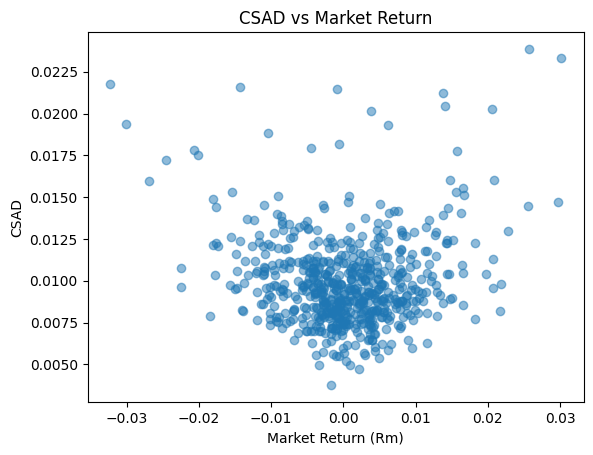

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(df['Rm'], df['CSAD'], alpha=0.5)
plt.xlabel('Market Return (Rm)')
plt.ylabel('CSAD')
plt.title('CSAD vs Market Return')

plt.savefig("figure1_csad_vs_rm.png")
plt.show()

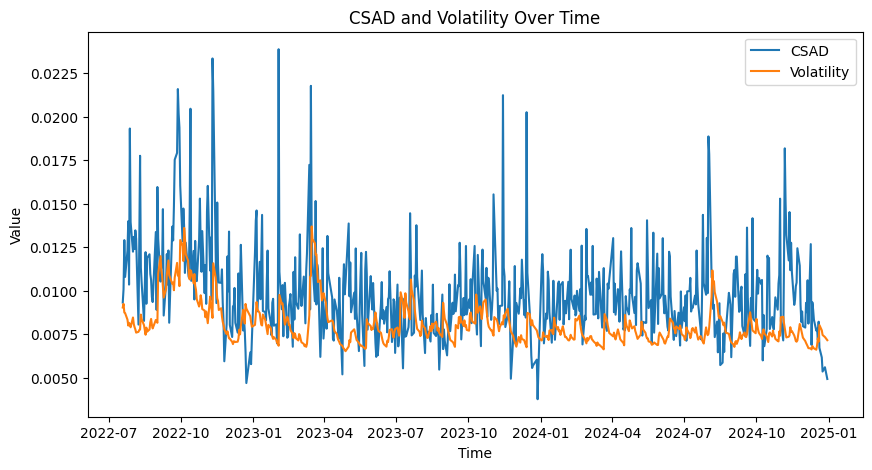

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(df.index, df['CSAD'], label='CSAD')
plt.plot(df.index, df['volatility'], label='Volatility')

plt.legend()
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('CSAD and Volatility Over Time')

plt.savefig("figure2_timeseries.png")
plt.show()

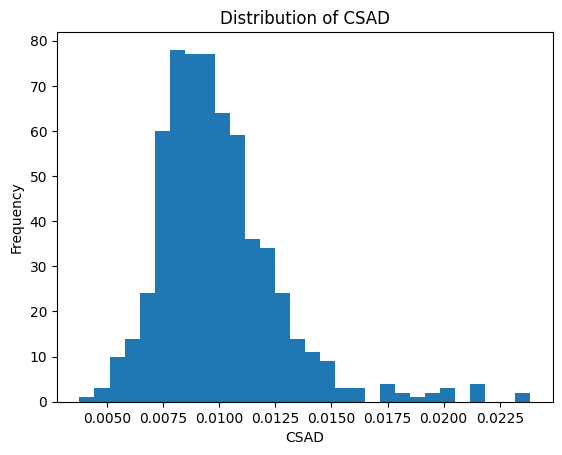

In [ ]:
plt.hist(df['CSAD'], bins=30)
plt.xlabel('CSAD')
plt.ylabel('Frequency')
plt.title('Distribution of CSAD')

plt.savefig("figure3_histogram_csad.png")
plt.show()

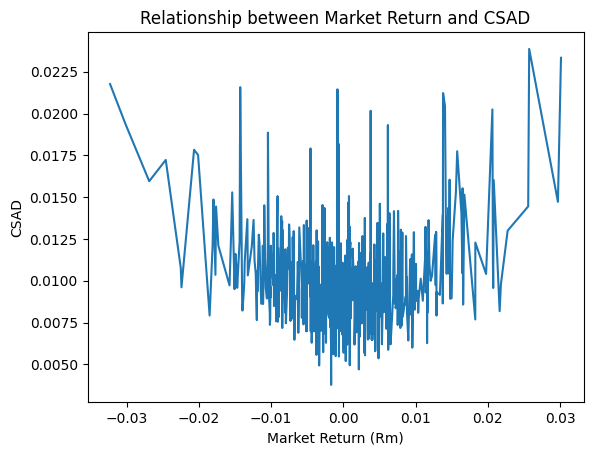

In [ ]:
df_sorted = df.sort_values(by='Rm')

plt.plot(df_sorted['Rm'], df_sorted['CSAD'])
plt.xlabel('Market Return (Rm)')
plt.ylabel('CSAD')
plt.title('Relationship between Market Return and CSAD')

plt.savefig("figure4_line_csad_rm.png")
plt.show()

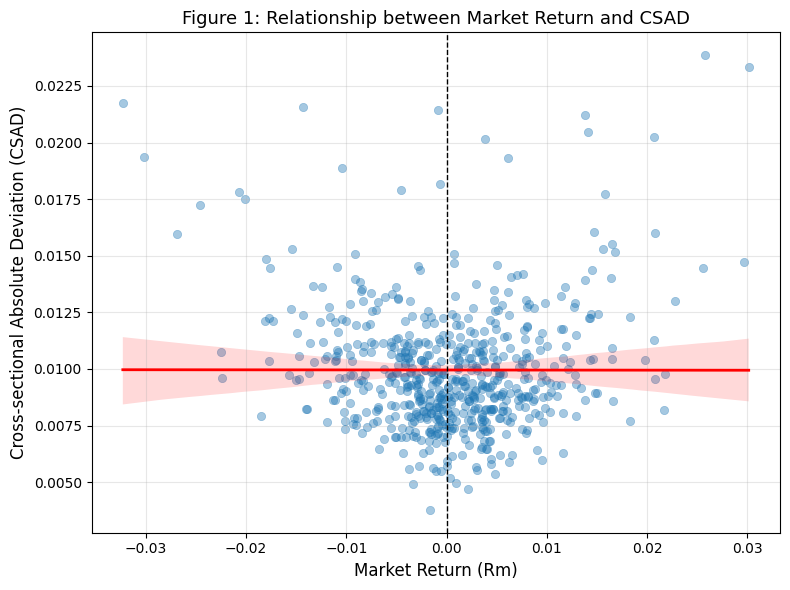

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

# Scatter with transparency (reduces overlap problem)
sns.scatterplot(x=df['Rm'], y=df['CSAD'], alpha=0.4, edgecolor=None)

# Add regression (trend) line
sns.regplot(x=df['Rm'], y=df['CSAD'],
            scatter=False,
            color='red',
            line_kws={'linewidth':2})

# Add zero line (important for interpretation)
plt.axvline(0, color='black', linestyle='--', linewidth=1)

# Labels (more academic)
plt.xlabel('Market Return (Rm)', fontsize=12)
plt.ylabel('Cross-sectional Absolute Deviation (CSAD)', fontsize=12)

# Academic title
plt.title('Figure 1: Relationship between Market Return and CSAD', fontsize=13)

# Improve layout
plt.grid(True, alpha=0.3)

plt.tight_layout()

# Save high-quality image
plt.savefig("figure1_improved.png", dpi=300)

plt.show()

<Axes: xlabel='Rm', ylabel='CSAD'>

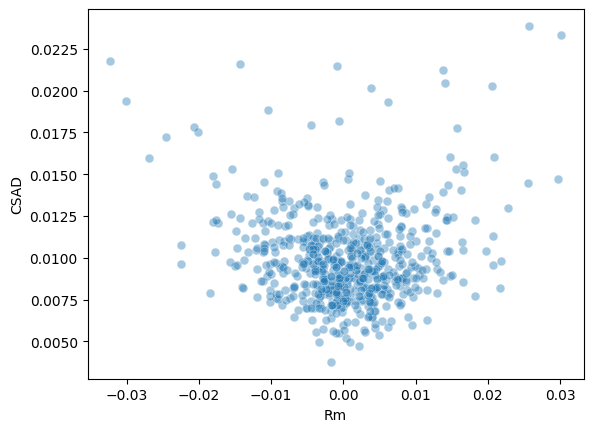

In [ ]:
sns.scatterplot(x=df['Rm'], y=df['CSAD'], alpha=0.4, s=40)

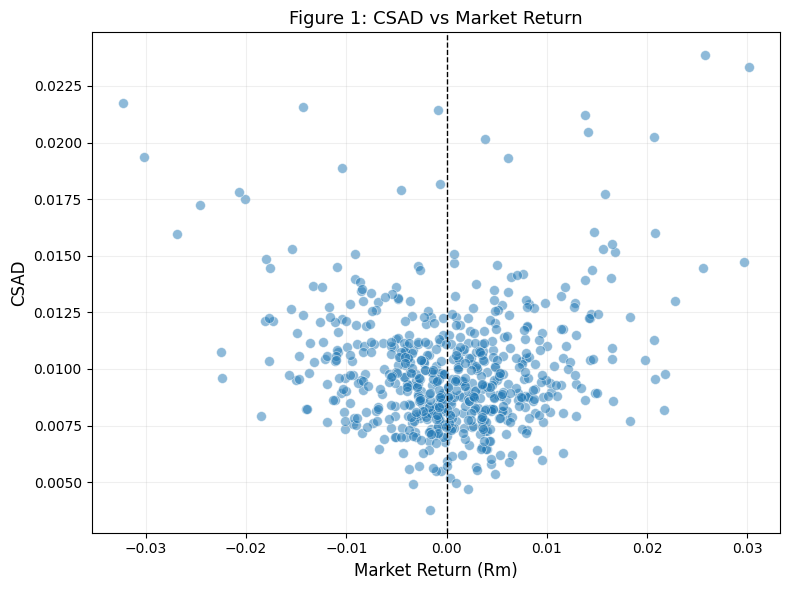

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

# Clean scatter
sns.scatterplot(
    x=df['Rm'],
    y=df['CSAD'],
    alpha=0.5,
    s=50
)

# Zero reference line (keep this — VERY IMPORTANT)
plt.axvline(0, color='black', linestyle='--', linewidth=1)

# Labels
plt.xlabel('Market Return (Rm)', fontsize=12)
plt.ylabel('CSAD', fontsize=12)

# Title
plt.title('Figure 1: CSAD vs Market Return', fontsize=13)

# Light grid
plt.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("figure1_clean.png", dpi=300)
plt.show()

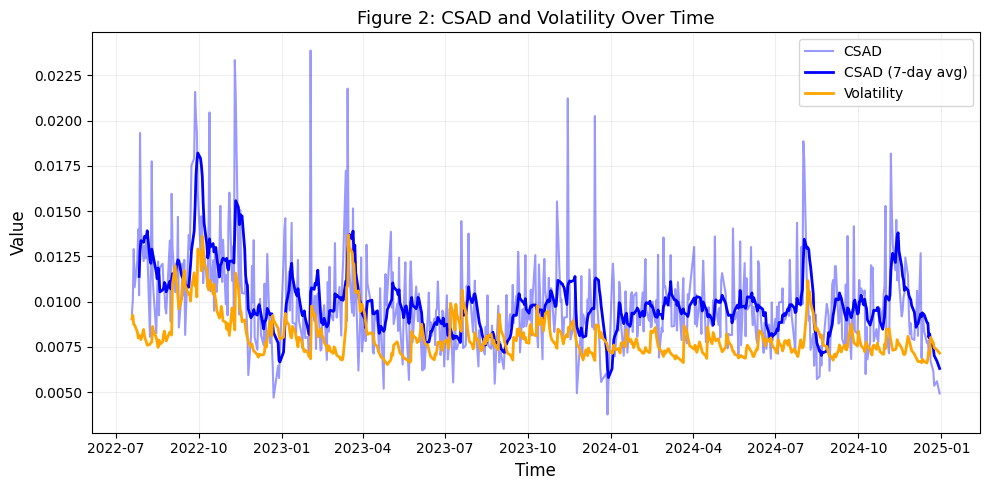

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

# Plot original CSAD (lighter color)
plt.plot(df.index, df['CSAD'], color='blue', alpha=0.4, label='CSAD')

# Smooth CSAD (7-day moving average)
plt.plot(df.index, df['CSAD'].rolling(7).mean(),
         color='blue', linewidth=2, label='CSAD (7-day avg)')

# Plot volatility
plt.plot(df.index, df['volatility'],
         color='orange', linewidth=2, label='Volatility')

# Labels
plt.xlabel('Time', fontsize=12)
plt.ylabel('Value', fontsize=12)

# Title
plt.title('Figure 2: CSAD and Volatility Over Time', fontsize=13)

# Legend
plt.legend()

# Clean grid
plt.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("figure2_improved.png", dpi=300)
plt.show()

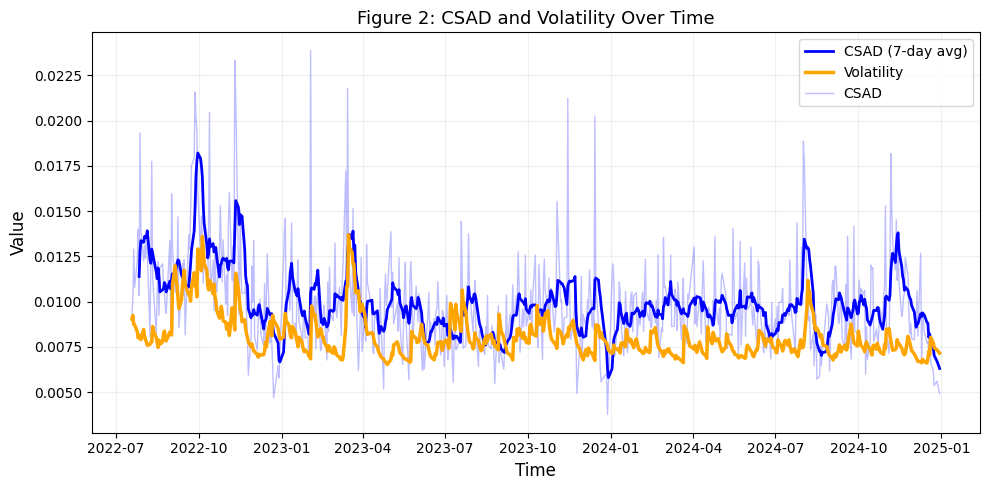

In [ ]:
import matplotlib.pyplot as plt

# Create figure
plt.figure(figsize=(10,5))

# -----------------------------
# 1. Plot RAW CSAD (lighter)
# -----------------------------
plt.plot(
    df.index,
    df['CSAD'],
    color='blue',
    alpha=0.25,
    linewidth=1,
    label='CSAD'
)

# -----------------------------
# 2. Plot SMOOTHED CSAD (7-day moving average)
# -----------------------------
plt.plot(
    df.index,
    df['CSAD'].rolling(7).mean(),
    color='blue',
    linewidth=2,
    label='CSAD (7-day avg)'
)

# -----------------------------
# 3. Plot VOLATILITY
# -----------------------------
plt.plot(
    df.index,
    df['volatility'],
    color='orange',
    linewidth=2.5,
    label='Volatility'
)

# -----------------------------
# 4. Labels
# -----------------------------
plt.xlabel('Time', fontsize=12)
plt.ylabel('Value', fontsize=12)

# -----------------------------
# 5. Title
# -----------------------------
plt.title('Figure 2: CSAD and Volatility Over Time', fontsize=13)

# -----------------------------
# 6. Legend (better order)
# -----------------------------
handles, labels = plt.gca().get_legend_handles_labels()

plt.legend(
    handles=[handles[1], handles[2], handles[0]],
    labels=[labels[1], labels[2], labels[0]]
)

# -----------------------------
# 7. Grid
# -----------------------------
plt.grid(True, alpha=0.2)

# -----------------------------
# 8. Layout
# -----------------------------
plt.tight_layout()

# -----------------------------
# 9. Save high-quality image
# -----------------------------
plt.savefig("figure2_final.png", dpi=300)

# -----------------------------
# 10. Show plot
# -----------------------------
plt.show()

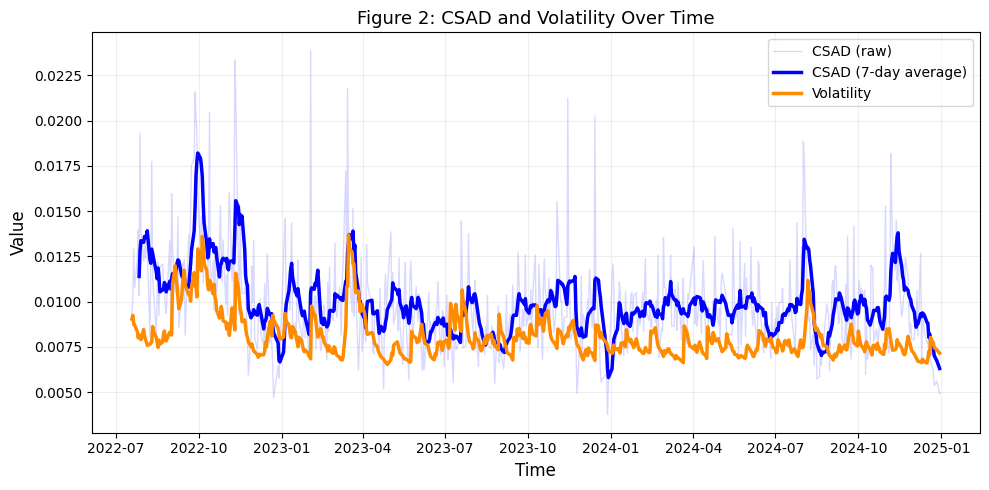

In [ ]:
import matplotlib.pyplot as plt

# Create figure
plt.figure(figsize=(10,5))

# ---------------------------
# 1. Raw CSAD (very light)
# ---------------------------
plt.plot(
    df.index,
    df['CSAD'],
    color='blue',
    alpha=0.15,
    linewidth=1,
    label='CSAD (raw)'
)

# ---------------------------
# 2. Smoothed CSAD (focus line)
# ---------------------------
plt.plot(
    df.index,
    df['CSAD'].rolling(7).mean(),
    color='blue',
    linewidth=2.5,
    label='CSAD (7-day average)'
)

# ---------------------------
# 3. Volatility (clear contrast)
# ---------------------------
plt.plot(
    df.index,
    df['volatility'],
    color='darkorange',
    linewidth=2.5,
    label='Volatility'
)

# ---------------------------
# 4. Labels
# ---------------------------
plt.xlabel('Time', fontsize=12)
plt.ylabel('Value', fontsize=12)

# ---------------------------
# 5. Title
# ---------------------------
plt.title('Figure 2: CSAD and Volatility Over Time', fontsize=13)

# ---------------------------
# 6. Grid
# ---------------------------
plt.grid(True, alpha=0.2)

# ---------------------------
# 7. Legend (clean order)
# ---------------------------
plt.legend()

# ---------------------------
# 8. Improve layout
# ---------------------------
plt.tight_layout()

# ---------------------------
# 9. Save high-quality figure
# ---------------------------
plt.savefig("figure2_final_submission.png", dpi=300)

# ---------------------------
# 10. Show figure
# ---------------------------
plt.show()

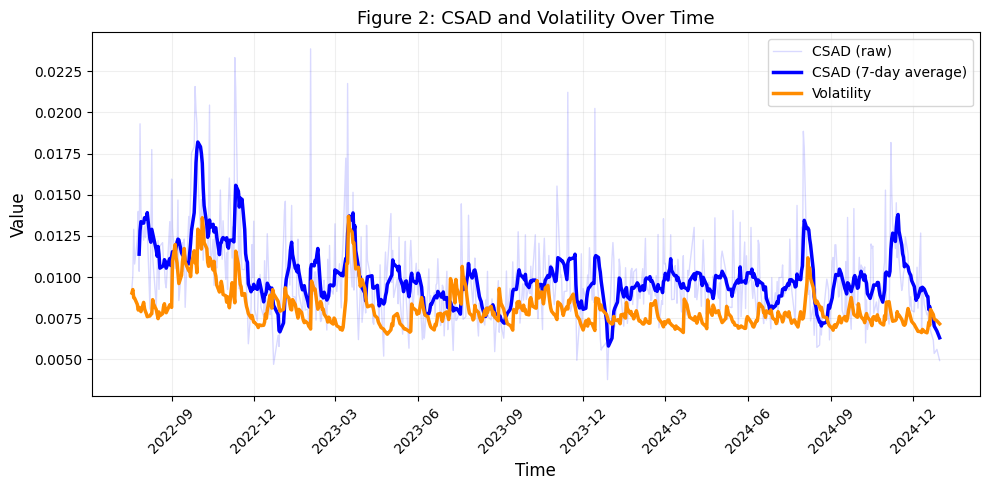

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Create figure
plt.figure(figsize=(10,5))

# Raw CSAD (very light)
plt.plot(
    df.index,
    df['CSAD'],
    color='blue',
    alpha=0.15,
    linewidth=1,
    label='CSAD (raw)'
)

# Smoothed CSAD
plt.plot(
    df.index,
    df['CSAD'].rolling(7).mean(),
    color='blue',
    linewidth=2.5,
    label='CSAD (7-day average)'
)

# Volatility
plt.plot(
    df.index,
    df['volatility'],
    color='darkorange',
    linewidth=2.5,
    label='Volatility'
)

# Labels
plt.xlabel('Time', fontsize=12)
plt.ylabel('Value', fontsize=12)

# Title
plt.title('Figure 2: CSAD and Volatility Over Time', fontsize=13)

# Grid
plt.grid(True, alpha=0.2)

# Improve date formatting (clean x-axis)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xticks(rotation=45)

# Legend
plt.legend()

# Layout
plt.tight_layout()

# Save
plt.savefig("figure2_final_submission.png", dpi=300)

# Show
plt.show()

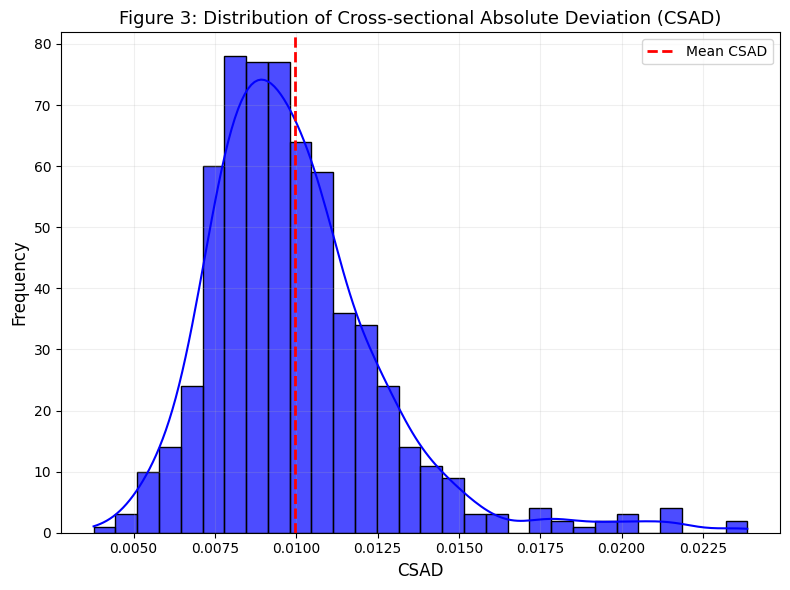

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

# -----------------------------------
# Histogram with density
# -----------------------------------
sns.histplot(
    df['CSAD'],
    bins=30,
    kde=True,
    color='blue',
    edgecolor='black',
    alpha=0.7
)

# -----------------------------------
# Mean line (VERY IMPORTANT)
# -----------------------------------
plt.axvline(
    df['CSAD'].mean(),
    color='red',
    linestyle='--',
    linewidth=2,
    label='Mean CSAD'
)

# -----------------------------------
# Labels
# -----------------------------------
plt.xlabel('CSAD', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# -----------------------------------
# Title (academic style)
# -----------------------------------
plt.title('Figure 3: Distribution of Cross-sectional Absolute Deviation (CSAD)', fontsize=13)

# -----------------------------------
# Grid
# -----------------------------------
plt.grid(True, alpha=0.2)

# -----------------------------------
# Legend
# -----------------------------------
plt.legend()

# -----------------------------------
# Layout
# -----------------------------------
plt.tight_layout()

# -----------------------------------
# Save high-quality image
# -----------------------------------
plt.savefig("figure3_final_submission.png", dpi=300)

# -----------------------------------
# Show plot
# -----------------------------------
plt.show()

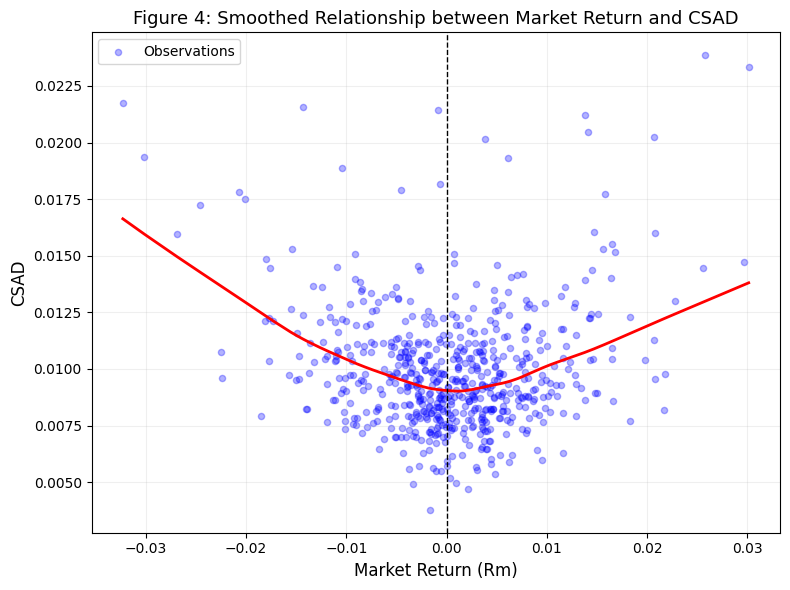

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort dataset by Rm
df_sorted = df.sort_values(by='Rm')

# Create figure
plt.figure(figsize=(8,6))

# ---------------------------
# 1. Scatter (light — shows distribution)
# ---------------------------
plt.scatter(
    df_sorted['Rm'],
    df_sorted['CSAD'],
    alpha=0.3,
    s=20,
    color='blue',
    label='Observations'
)

# ---------------------------
# 2. Smooth curve (important part)
# ---------------------------
sns.regplot(
    x=df_sorted['Rm'],
    y=df_sorted['CSAD'],
    scatter=False,
    lowess=True,   # smoothing
    color='red',
    line_kws={'linewidth':2, 'label':'Smoothed relationship'}
)

# ---------------------------
# 3. Reference line at zero
# ---------------------------
plt.axvline(0, color='black', linestyle='--', linewidth=1)

# ---------------------------
# 4. Labels
# ---------------------------
plt.xlabel('Market Return (Rm)', fontsize=12)
plt.ylabel('CSAD', fontsize=12)

# ---------------------------
# 5. Title
# ---------------------------
plt.title('Figure 4: Smoothed Relationship between Market Return and CSAD', fontsize=13)

# ---------------------------
# 6. Grid
# ---------------------------
plt.grid(True, alpha=0.2)

# ---------------------------
# 7. Legend
# ---------------------------
plt.legend()

# ---------------------------
# 8. Layout
# ---------------------------
plt.tight_layout()

# ---------------------------
# 9. Save
# ---------------------------
plt.savefig("figure4_final.png", dpi=300)

# ---------------------------
# 10. Show
# ---------------------------
plt.show()

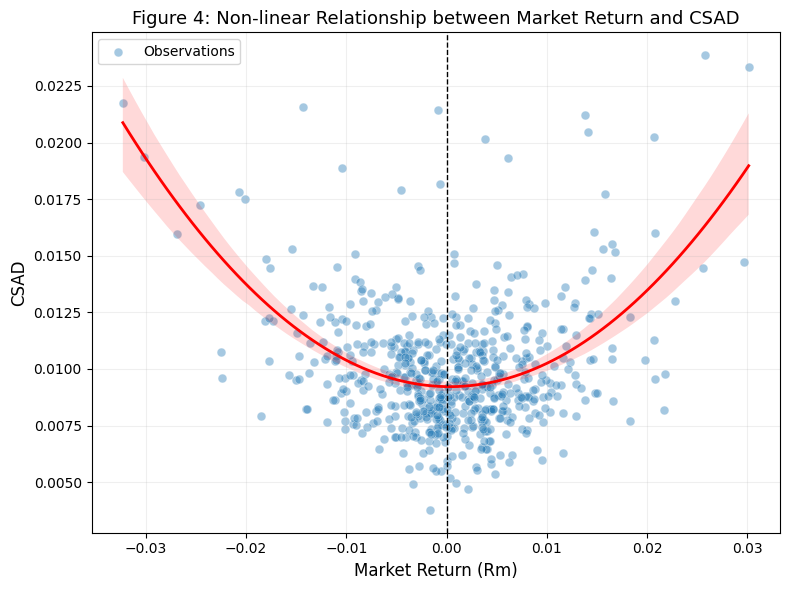

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

# Scatter plot
sns.scatterplot(
    x=df['Rm'],
    y=df['CSAD'],
    alpha=0.4,
    s=40,
    label='Observations'
)

# Non-linear (quadratic) regression line
sns.regplot(
    x=df['Rm'],
    y=df['CSAD'],
    scatter=False,
    order=2,
    color='red',
    line_kws={'linewidth':2}
)

# Zero reference line
plt.axvline(0, color='black', linestyle='--', linewidth=1)

# Labels
plt.xlabel('Market Return (Rm)', fontsize=12)
plt.ylabel('CSAD', fontsize=12)

# Title
plt.title('Figure 4: Non-linear Relationship between Market Return and CSAD', fontsize=13)

# Grid
plt.grid(True, alpha=0.2)

# Legend
plt.legend()

# Layout
plt.tight_layout()

# Save
plt.savefig("figure4_final_submission.png", dpi=300)

# Show
plt.show()